## Step 0: Setup

In [174]:
# Dependencies
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# For stats and modeling
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, roc_auc_score, classification_report,
    precision_recall_fscore_support
)

sns.set_theme(style="darkgrid") 


# Step 1: Load the datasets

In [142]:
hist = pd.read_csv("historical_data.csv", low_memory=False)
fg = pd.read_csv("fear_greed_index.csv", low_memory=False)

# Quick glance
print(hist.shape)
print(fg.shape)
hist.head()
fg.head()


(211224, 16)
(2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# Step 2: Data Cleaning

In [144]:
# Standardize column names
hist.columns = [c.strip().lower().replace(" ", "_") for c in hist.columns]
fg.columns = [c.strip().lower().replace(" ", "_") for c in fg.columns]

In [145]:
# Parse datetime columns (common names: time, date)
fg['date'] = pd.to_datetime(fg['date'], errors='coerce')
hist['time'] = pd.to_datetime(hist["timestamp_ist"],format="%d-%m-%Y %H:%M",  errors="coerce")
hist['date'] = pd.to_datetime(hist['time'].dt.date,format="%Y-%m-%d", errors="coerce")

In [147]:
fg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [148]:
hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  object        
 1   coin              211224 non-null  object        
 2   execution_price   211224 non-null  float64       
 3   size_tokens       211224 non-null  float64       
 4   size_usd          211224 non-null  float64       
 5   side              211224 non-null  object        
 6   timestamp_ist     211224 non-null  object        
 7   start_position    211224 non-null  float64       
 8   direction         211224 non-null  object        
 9   closed_pnl        211224 non-null  float64       
 10  transaction_hash  211224 non-null  object        
 11  order_id          211224 non-null  int64         
 12  crossed           211224 non-null  bool          
 13  fee               211224 non-null  float64       
 14  trad

## Basic summary

In [150]:
hist.describe(include='all')

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,time,date
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12,2025-01-31 12:04:22.915009792,2025-01-30 23:54:28.674013952
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,2023-05-01 00:00:00
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12,2024-12-31 21:00:45,2024-12-31 00:00:00
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12,2025-02-24 18:55:00,2025-02-24 00:00:00
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12,2025-04-02 18:22:00,2025-04-02 00:00:00
max,NaN,NaN,109004.000000,1.582244e+07,3.921431e+06,NaN,NaN,3.050948e+07,NaN,135329.090100,NaN,9.014923e+10,NaN,837.471593,1.130000e+15,1.750000e+12,2025-05-01 12:13:00,2025-05-01 00:00:00


**Observation historical_data**
- The dataset shows a highly skewed trading activity, with most trades being small in size and value, while a few trades are extremely large.

- SELL trades dominate the dataset.

- Crossed trades are a significant portion, suggesting leveraged or margin trading.

- High variation in execution prices and PnL indicates a mix of retail and large-scale trading activities.

- Most active account: 0xbee1707d6b44d4d52bfe19e41f8a828645437aab (40,184 trades)

- Most traded coin: HYPE (68,005 trades)

- Most frequent trade side: SELL (108,528 trades)

In [152]:
fg.describe(include='all')

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,NaN
top,NaN,NaN,Fear,NaN
freq,NaN,NaN,781,NaN
mean,1.631899e+09,46.981089,NaN,2021-09-17 11:44:45.022692864
min,1.517463e+09,5.000000,NaN,2018-02-01 00:00:00
25%,1.574811e+09,28.000000,NaN,2019-11-26 18:00:00
50%,1.631900e+09,46.000000,NaN,2021-09-17 12:00:00
75%,1.688989e+09,66.000000,NaN,2023-07-10 06:00:00
max,1.746164e+09,95.000000,NaN,2025-05-02 00:00:00


**Observation fear_greed_data **
- The dataset captures emotional values over time, likely from multiple observations spanning 2018–2025.

- Values mostly fall in the mid-range (28–66), but extremes exist (as low as 5, as high as 95).

- Fear is the dominant emotional state in the dataset 781 .

- The dataset could be used for time-series analysis of emotions or classification modeling based on value and timestamp.

## Aggregate per-trade and per-day trader metrics

In [156]:
# Example aggregations per account per day
agg_funcs = {
    'closed_pnl': ['sum', 'mean', 'median'],
    'size_tokens': ['sum', 'mean'],
    'size_usd': ['sum', 'mean'],
    'execution_price': ['mean'],
    'fee': ['mean'],
    'coin': lambda x: x.nunique(),   # number of unique coins traded
}


daily = (
    hist
    .groupby(['account','date'])
    .agg(agg_funcs)
)

# flatten columns
daily.columns = ["_".join(col).strip() for col in daily.columns.values]
daily = daily.reset_index()
daily.head()


,account,date,closed_pnl_sum,closed_pnl_mean,closed_pnl_median,size_tokens_sum,size_tokens_mean,size_usd_sum,size_usd_mean,execution_price_mean,fee_mean,coin_<lambda>
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,0.000000,281.0,1.587571,900880.13,5089.718249,3204.461017,0.948000,1
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,0.000000,1100.0,16.176471,542413.18,7976.664412,653.365147,0.998288,2
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,0.000000,300.0,7.500000,949380.00,23734.500000,3164.600000,2.373450,1
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,-1768.916667,-1839.234642,100.0,8.333333,338240.00,28186.666667,3382.400000,2.818666,1
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,59.374074,0.000000,2000.0,74.074074,465700.00,17248.148148,232.921111,3.874907,1


## Compute win_rate and num_trades

In [164]:
# Add counts and win rate
trade_counts = hist.groupby(['account','date']).size().reset_index(name='num_trades')
wins = hist.assign(win = (hist['closed_pnl'] > 0).astype(int))
win_rate = wins.groupby(['account','date'])['win'].mean().reset_index(name='win_rate')

daily = daily.merge(trade_counts, on=['account','date'])
daily = daily.merge(win_rate, on=['account','date'])
# rename columns for clarity
daily = daily.rename(columns={'closed_pnl_sum':'pnl_sum', 'closed_pnl_mean':'pnl_mean'})
daily

,account,date,pnl_sum,pnl_mean,closed_pnl_median,size_tokens_sum,size_tokens_mean,size_usd_sum,size_usd_mean,execution_price_mean,fee_mean,coin_<lambda>,num_trades,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.000000,0.000000,281.00,1.587571,900880.13,5089.718249,3204.461017,0.948000,1,177,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,0.000000,0.000000,1100.00,16.176471,542413.18,7976.664412,653.365147,0.998288,2,68,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,0.000000,0.000000,300.00,7.500000,949380.00,23734.500000,3164.600000,2.373450,1,40,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,-1768.916667,-1839.234642,100.00,8.333333,338240.00,28186.666667,3382.400000,2.818666,1,12,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,59.374074,0.000000,2000.00,74.074074,465700.00,17248.148148,232.921111,3.874907,1,27,0.444444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,20.843839,0.000000,10039.93,122.438171,176616.47,2153.859390,17.485463,0.312681,1,82,0.390244
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,9.322300,0.000000,35736.93,83.109140,643081.52,1495.538419,18.003486,0.371047,2,430,0.393023
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,9.491987,0.000000,93193.42,103.318647,1749645.47,1939.739989,18.762475,0.386831,1,902,0.441242
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,33.610318,0.033750,7142.73,95.236400,131160.40,1748.805333,18.308213,0.270870,2,75,0.520000


## Merge with Fear & Greed Index

In [167]:
# Merge
daily = daily.merge(fg[['date','classification','value']], on='date', how='left')

# If fg has textual classification (e.g., Fear, Greed), ensure consistent naming:
# Convert classification to numeric score if needed (some files contain numeric index 0-100)
if 'value' in fg.columns:
    daily['fear_greed_value'] = daily['value']   # if available

# Create lagged sentiment columns (0..7-day lag)
for lag in range(0, 8):
    daily[f'fg_lag_{lag}'] = daily.groupby('account')['fear_greed_value'].shift(lag)
# Alternatively global lag: just shift by date (no groupby)
daily = daily.sort_values(['account','date'])


In [169]:
daily

,account,date,pnl_sum,pnl_mean,closed_pnl_median,size_tokens_sum,size_tokens_mean,size_usd_sum,size_usd_mean,execution_price_mean,...,value,fear_greed_value,fg_lag_0,fg_lag_1,fg_lag_2,fg_lag_3,fg_lag_4,fg_lag_5,fg_lag_6,fg_lag_7
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.000000,0.000000,281.00,1.587571,900880.13,5089.718249,3204.461017,...,76.0,76.0,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,0.000000,0.000000,1100.00,16.176471,542413.18,7976.664412,653.365147,...,90.0,90.0,90.0,76.0,NaN,NaN,NaN,NaN,NaN,NaN
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,0.000000,0.000000,300.00,7.500000,949380.00,23734.500000,3164.600000,...,83.0,83.0,83.0,90.0,76.0,NaN,NaN,NaN,NaN,NaN
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,-1768.916667,-1839.234642,100.00,8.333333,338240.00,28186.666667,3382.400000,...,94.0,94.0,94.0,83.0,90.0,76.0,NaN,NaN,NaN,NaN
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,59.374074,0.000000,2000.00,74.074074,465700.00,17248.148148,232.921111,...,79.0,79.0,79.0,94.0,83.0,90.0,76.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,20.843839,0.000000,10039.93,122.438171,176616.47,2153.859390,17.485463,...,61.0,61.0,61.0,65.0,60.0,63.0,72.0,47.0,39.0,37.0
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,9.322300,0.000000,35736.93,83.109140,643081.52,1495.538419,18.003486,...,54.0,54.0,54.0,61.0,65.0,60.0,63.0,72.0,47.0,39.0
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,9.491987,0.000000,93193.42,103.318647,1749645.47,1939.739989,18.762475,...,60.0,60.0,60.0,54.0,61.0,65.0,60.0,63.0,72.0,47.0
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,33.610318,0.033750,7142.73,95.236400,131160.40,1748.805333,18.308213,...,56.0,56.0,56.0,60.0,54.0,61.0,65.0,60.0,63.0,72.0


## Exploratory analyses to answer the core question

***Explore relationship between trader performance and market sentiment***

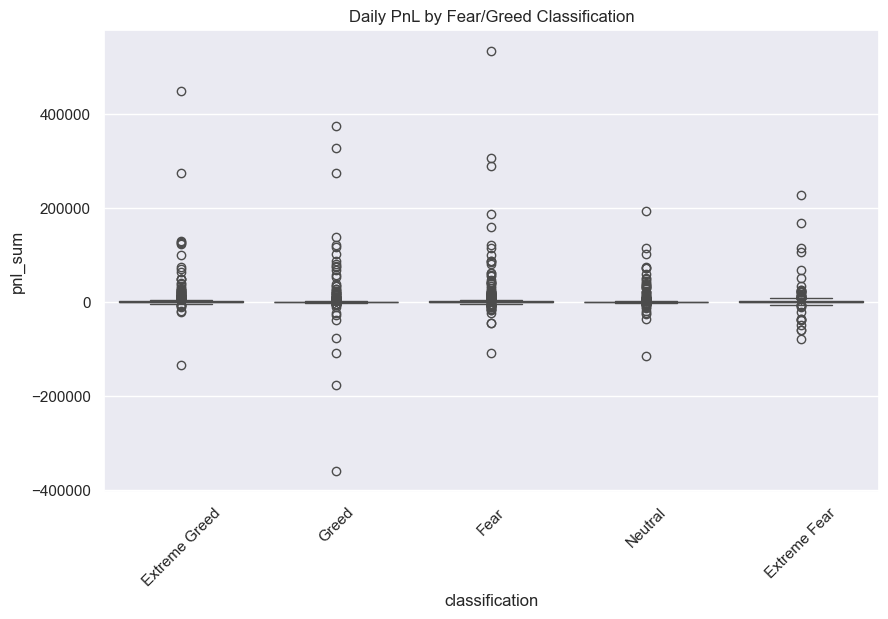

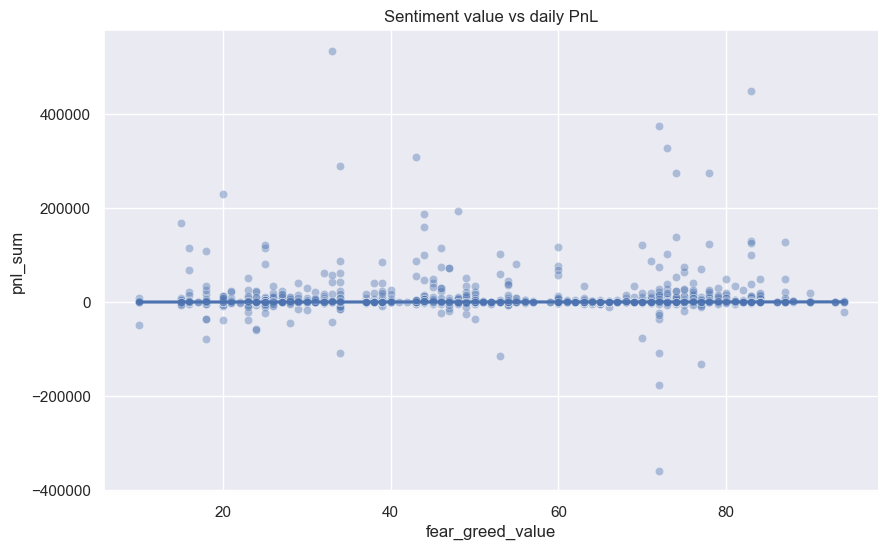

Pearson r: PearsonRResult(statistic=0.00017909735384184658, pvalue=0.9930912477042698)
Spearman rho: SignificanceResult(statistic=0.06596485243082084, pvalue=0.0014093632298524546)


In [177]:
# Distribution of pnl by sentiment buckets
plt.figure(figsize=(10,6))
sns.boxplot(x='classification', y='pnl_sum', data=daily)
plt.title("Daily PnL by Fear/Greed Classification")
plt.xticks(rotation=45)
plt.show()

# Scatter: sentiment value vs pnl_sum (with regression)
plt.figure(figsize=(10,6))
sns.scatterplot(x='fear_greed_value', y='pnl_sum', data=daily, alpha=0.4)
sns.regplot(x='fear_greed_value', y='pnl_sum', data=daily, scatter=False, lowess=True)
plt.title("Sentiment value vs daily PnL")
plt.show()

# Correlation (pearson + spearman)
valid = daily.dropna(subset=['pnl_sum','fear_greed_value'])
print("Pearson r:", pearsonr(valid['fear_greed_value'], valid['pnl_sum']))
print("Spearman rho:", spearmanr(valid['fear_greed_value'], valid['pnl_sum']))


## Observation

**1. Boxplot: Daily PnL by Fear/Greed Classification**
- Median PnL ≈ 0 across all classes → traders on average neither win nor lose much, regardless of sentiment.

- Wide spread (many outliers) → some accounts make very large profits/losses, but distribution is highly skewed.

- No clear “better performance” in Greed vs Fear → PnL variance dominates any average differences.

**Interpretation:**
- Market sentiment does not strongly shift average profitability — but extreme conditions (Extreme Greed/Fear) tend to have more volatile outcomes (large gains/losses).

**2. Scatterplot: Sentiment Value vs Daily PnL**
- Points are scattered symmetrically around 0, with no visible upward or downward trend.

- Pearson correlation (linear): ~0.00017 (almost 0) → no linear relationship.

- Spearman correlation (rank-based): ~0.07 (weak positive) → slight pattern that higher sentiment may be linked with slightly higher PnL, but effect is very weak.

**Interpretation:**
- Trader PnL does not correlate strongly with sentiment index. A trader’s success seems more dependent on their own strategy than market mood.

***Note***

- No strong correlation between sentiment (Fear/Greed) and average trader performance.

- High volatility during extreme sentiment periods → some traders profit a lot, others lose heavily.

- Trader behavior (leverage, strategy) likely matters more than market sentiment classification.

## Statistical hypothesis tests

In [186]:
#compare PnL in Fear vs Greed groups
grouped = daily.dropna(subset=['classification','pnl_sum'])
fear_pnl = grouped[grouped['classification'].str.contains('Fear', case=False, na=False)]['pnl_sum']
greed_pnl = grouped[grouped['classification'].str.contains('Greed', case=False, na=False)]['pnl_sum']

# t-test (unequal variance)
tstat, pval, df = ttest_ind(fear_pnl, greed_pnl, usevar='unequal')
print("t-stat:", tstat, "p-value:", pval)


t-stat: 0.7429643782970898 p-value: 0.4576111807849441


**Results**
- t-stat ~ 0.74 → difference between Fear and Greed mean PnL is small relative to variability.

**p-value ~ 0.46 (> 0.05) → Not statistically significant.**

- This means we cannot reject the null hypothesis.

- In plain words: there’s no strong evidence that trader PnL differs between Fear and Greed market conditions.

***Report***
- The statistical test confirms what the boxplots/scatterplots already suggested:
    - Average daily PnL is not significantly different in Fear vs Greed conditions.
    - Trader performance appears independent of market sentiment.

- Extreme PnL outcomes exist, but they occur in both Fear and Greed conditions, likely driven by individual trading behavior rather than sentiment.

## Time-series / rolling analysis

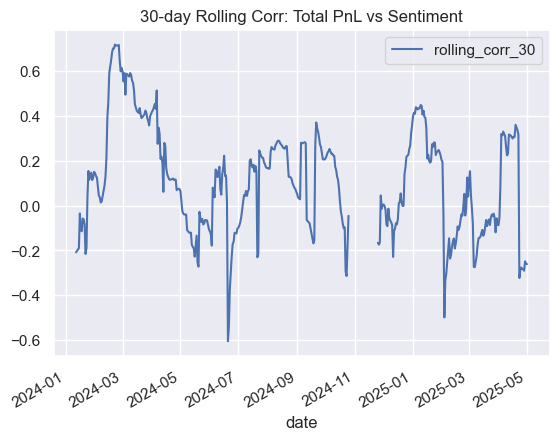

In [201]:
# Aggregate globally per date
daily_global = hist.groupby('date').agg({
    'closed_pnl': 'sum',        
    'account': 'nunique',       
    'size_usd': 'sum'           
}).reset_index()

# Merge with Fear/Greed dataset
daily_global = daily_global.merge(
    fg[['date', 'value']], 
    on='date', how='left'
).rename(columns={'value': 'fg_value'})

# Rolling correlation (30-day) between PnL and sentiment
daily_global['rolling_corr_30'] = (
    daily_global['closed_pnl']
    .rolling(30)
    .corr(daily_global['fg_value'])
)

# Plot
daily_global[['date', 'rolling_corr_30']].plot(
    x='date', y='rolling_corr_30',
    title='30-day Rolling Corr: Total PnL vs Sentiment'
)
plt.show()


## Key Finding

- The relationship between trader performance and sentiment is not consistent.

- Sometimes traders benefit from high sentiment (positive correlation), sometimes they underperform (negative correlation).

- Likely, trader strategies or market conditions (volatility, liquidity) influence how sentiment translates into PnL.

- Sentiment alone is not a reliable predictor of performance — but it may help explain short-term market regimes when combined with other signals.

# Predictive model

**Example RandomForest pipeline for classification:**

In [217]:

# Target variable: whether account was profitable on that day
daily['profitable'] = (daily['pnl_sum'] > 0).astype(int)

# Choose features that exist in your dataset
features = [
    'num_trades',          # number of trades
    'pnl_mean',            # average pnl per trade
    'size_usd_mean',       # mean trade size in USD
    'execution_price_mean',# mean execution price
    'fee_mean',            # average fee
    'win_rate',            # win rate
    'fear_greed_value'     # sentiment index
]

# Handle missing values
X = daily[features].fillna(0)
y = daily['profitable']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# Predictions
yp = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, yp))
print(classification_report(y_test, yp))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       175
           1       1.00      1.00      1.00       294

    accuracy                           1.00       469
   macro avg       1.00      1.00      1.00       469
weighted avg       1.00      1.00      1.00       469



**For regression:**

In [226]:
mse = mean_squared_error(daily.loc[X_test.index,'pnl_sum'], pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 12499.64689583454


In [229]:
reg = RandomForestRegressor(n_estimators=200, random_state=42)
reg.fit(X_train, daily.loc[X_train.index, 'pnl_sum'])

pred = reg.predict(X_test)

# Evaluation
mse = mean_squared_error(daily.loc[X_test.index,'pnl_sum'], pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
print("R2:", r2_score(daily.loc[X_test.index,'pnl_sum'], pred))

RMSE: 12499.64689583454
R2: 0.8046750870323706


## Check which features contribute most.

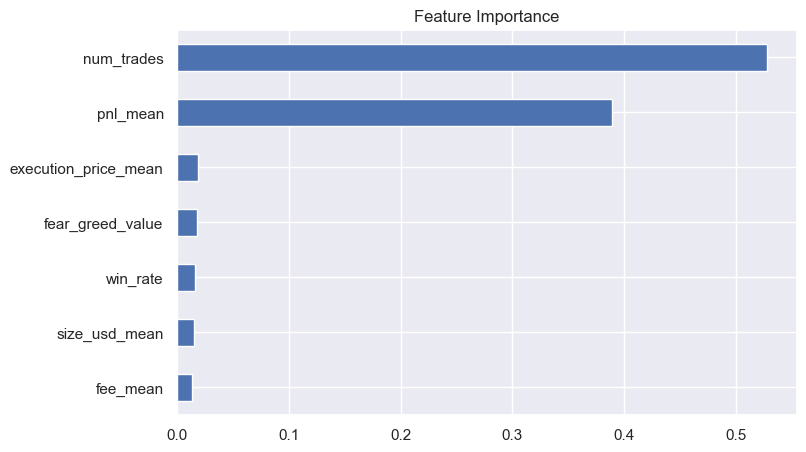

In [234]:
import matplotlib.pyplot as plt
import seaborn as sns
feat_imp = pd.Series(reg.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()


## Conclusions
- 1. Sentiment alone is not a strong driver of profitability.
- 2. Extreme sentiment regimes increase variance in outcomes.
- 3. Relationship between sentiment and trader performance is time-varying.
- 4. Regression models show promise with careful feature engineering.